In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import torch
import wandb
import sys
from pathlib import Path

In [2]:
PROJECT_ROOT = "/share/castor/home/e2406751/Superresolution-TIR"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from scripts.utils.dataset import SRDataset
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## MODEL

### edsr

In [3]:
from scripts.models.edsr import EDSRModule

api = wandb.Api()
artifact = api.artifact("ogalloethel-university-of-south-brittany/TIR_sisr/model-ahwj4f7j:best")
ckpt_dir = artifact.download("/tmp/ckpt")

# ogalloethel-university-of-south-brittany/TIR_sisr/nvstva26 
# ogalloethel-university-of-south-brittany/TIR_sisr/cfqoizag #256x256 
# ogalloethel-university-of-south-brittany/TIR_sisr/g27tc0ez #auxiliary


ckpt_path = next(
    os.path.join(ckpt_dir, f) for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")
)

model = EDSRModule.load_from_checkpoint(ckpt_path, map_location=device)
model.eval()

print("Loaded:", ckpt_path)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /share/home/e2406751/.netrc.
wandb:   1 of 1 files downloaded.  
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of 

[INFO] Loading pretrained: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Loaded 68 layers / 74 total
[INFO] Concat fusion enabled | aux_channels = 20
Loaded: /tmp/ckpt/model.ckpt


### swin 

In [4]:
from scripts.models.swinir import SwinIRModule

api = wandb.Api()
artifact = api.artifact("ogalloethel-university-of-south-brittany/TIR_sisr/model-buygc8q1:best")
ckpt_dir = artifact.download("/tmp/ckpt")

# ogalloethel-university-of-south-brittany/TIR_sisr/wqw9t468
# ogalloethel-university-of-south-brittany/TIR_sisr/buygc8q1 #256x256

ckpt_path = next(os.path.join(ckpt_dir, f) for f in os.listdir(ckpt_dir) if f.endswith(".ckpt"))

model = SwinIRModule.load_from_checkpoint(ckpt_path, map_location=device)
model.eval()

print("Loaded:", ckpt_path)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /share/home/e2406751/.netrc.
wandb: Downloading large artifact 'model-buygc8q1:best', 67.79MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:02.9 (23.7MB/s)
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. 

[INFO] DATA_RANGE set to 27.850130081176758°C 


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[INFO] Successfully replaced conv_last with 1-ch output.
[INFO] Loading pretrained SwinIR weights: /share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth
[INFO] Loaded 524/550 layers
Loaded: /tmp/ckpt/model.ckpt


### hat

In [3]:
from scripts.models.hat import HATModule

api = wandb.Api()
artifact = api.artifact("ogalloethel-university-of-south-brittany/TIR_sisr/model-zmzq912r:best")
ckpt_dir = artifact.download("/tmp/ckpt")

# ogalloethel-university-of-south-brittany/TIR_sisr/r8zqj6iq
# ogalloethel-university-of-south-brittany/TIR_sisr/zmzq912r #256x256


ckpt_path = next(
    os.path.join(ckpt_dir, f) for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")
)

model = HATModule.load_from_checkpoint(ckpt_path, map_location=device)
model.eval()

print("Loaded:", ckpt_path)

[INFO] basicsr HAT not found — fetching hat_arch from XPixelGroup/HAT on GitHub...


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /share/home/e2406751/.netrc.


[INFO] HAT arch loaded from GitHub and cached in sys.modules


wandb: Downloading large artifact 'model-zmzq912r:best', 84.27MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:02.4 (34.8MB/s)
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full contr

[INFO] DATA_RANGE set to 27.850130081176758°C


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[INFO] Loading pretrained HAT weights: /share/home/e2406751/Superresolution-TIR/data/pretrained/HAT_imagenet_x4.pth
[INFO] Loaded 854/864 layers
[INFO] Replaced conv_last: 3ch to 1ch
Loaded: /tmp/ckpt/model.ckpt


### realesrgan

In [3]:
from scripts.models.real_esrgan import RealESRGANModule

api = wandb.Api()
artifact = api.artifact("ogalloethel-university-of-south-brittany/TIR_sisr/model-64t0lawv:best")
ckpt_dir = artifact.download("/tmp/ckpt")

# ogalloethel-university-of-south-brittany/TIR_sisr/64t0lawv

ckpt_path = next(
    os.path.join(ckpt_dir, f) for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")
)

model = RealESRGANModule.load_from_checkpoint(ckpt_path, map_location=device)
model.eval()

print("Loaded:", ckpt_path)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /share/home/e2406751/.netrc.
wandb: Downloading large artifact 'model-64t0lawv:best', 191.36MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:01.6 (121.0MB/s)
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`

[INFO] DATA_RANGE set to 28.923696517944336°C
[INFO] Loading pretrained RRDBNet generator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_generator_x4.pth
[INFO] Generator: loaded 694/702 layers
[INFO] Loading pretrained discriminator: /share/home/e2406751/Superresolution-TIR/data/pretrained/RealESRGAN_discriminator_x4.pth
[INFO] Discriminator: loaded 27/28 layers
[INFO] Replaced conv_last: 3ch → 1ch


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded: /tmp/ckpt/model.ckpt


In [4]:
with open("data/full_metadata.json") as f:
    metadata = pd.DataFrame(json.load(f))

# for random
test_df  = metadata[metadata["split"] == "test"].reset_index(drop=True)

print("Test patches:", len(test_df))

Test patches: 129


In [5]:
# ds = SRDataset(
#     test_df,
#     mean=model.hparams.mean,
#     std=model.hparams.std,
#     patch_size=48,
#     is_train=False
# )

# aux
ds = SRDataset(
    test_df,
    mean=model.hparams.mean,
    std=model.hparams.std,
    aux_mean=model.hparams.aux_mean,
    aux_std=model.hparams.aux_std,
    is_train=False,
    transforms=None,
    use_aux=model.hparams.use_aux,
)

## Visualization

In [11]:

idx = 116
CMAP = "inferno"

# ---- Load sample ----
lr_t, hr_t, mask_t, aux_t = ds[idx]

lr_b  = lr_t.unsqueeze(0).to(device)
aux_b = aux_t.unsqueeze(0).to(device) if model.use_aux else None

# ---- Forward ----
with torch.no_grad():
    sr_t = model(lr_b, aux_b)

# ---- Denormalize ----
sr_np = model.denormalize(sr_t).cpu().numpy()[0, 0]
hr_np = model.denormalize(hr_t.unsqueeze(0)).cpu().numpy()[0, 0]
lr_np = model.denormalize(lr_t.unsqueeze(0)).cpu().numpy()[0, 0]

# ---- Masks ----
mask_hr = mask_t.numpy()[0] > 0.5
mask_sr = mask_hr

mask_lr = mask_hr.reshape(
    mask_hr.shape[0] // ds.scale, ds.scale,
    mask_hr.shape[1] // ds.scale, ds.scale
).mean(axis=(1, 3)) > 0.5

# ---- Metrics ----
data_range = float(model.DATA_RANGE)

def psnr_on_valid(pred, target, mask, data_range):
    mse = np.mean((pred[mask] - target[mask]) ** 2)
    return float("inf") if mse <= 1e-12 else 20*np.log10(data_range) - 10*np.log10(mse)

def mae_on_valid(pred, target, mask):
    return float(np.mean(np.abs(pred[mask] - target[mask])))

def rmse_on_valid(pred, target, mask):
    return float(np.sqrt(np.mean((pred[mask] - target[mask]) ** 2)))

def bias_on_valid(pred, target, mask):
    return float(np.mean((pred - target)[mask]))

metrics = {
    "PSNR (dB)": psnr_on_valid(sr_np, hr_np, mask_sr, data_range),
    "MAE  (°C)": mae_on_valid(sr_np, hr_np, mask_sr),
    "RMSE (°C)": rmse_on_valid(sr_np, hr_np, mask_sr),
    "Bias (°C)": bias_on_valid(sr_np, hr_np, mask_sr),
}

for name, val in metrics.items():
    sign = "+" if "Bias" in name and val >= 0 else ""
    print(f"SR {name}: {sign}{val:.3f}")

# ---- Apply masks ----
lr_final = np.where(mask_lr, lr_np, np.nan)
sr_final = np.where(mask_sr, sr_np, np.nan)
hr_final = np.where(mask_hr, hr_np, np.nan)

SR PSNR (dB): 20.406
SR MAE  (°C): 1.791
SR RMSE (°C): 2.543
SR Bias (°C): +0.210


### edsr

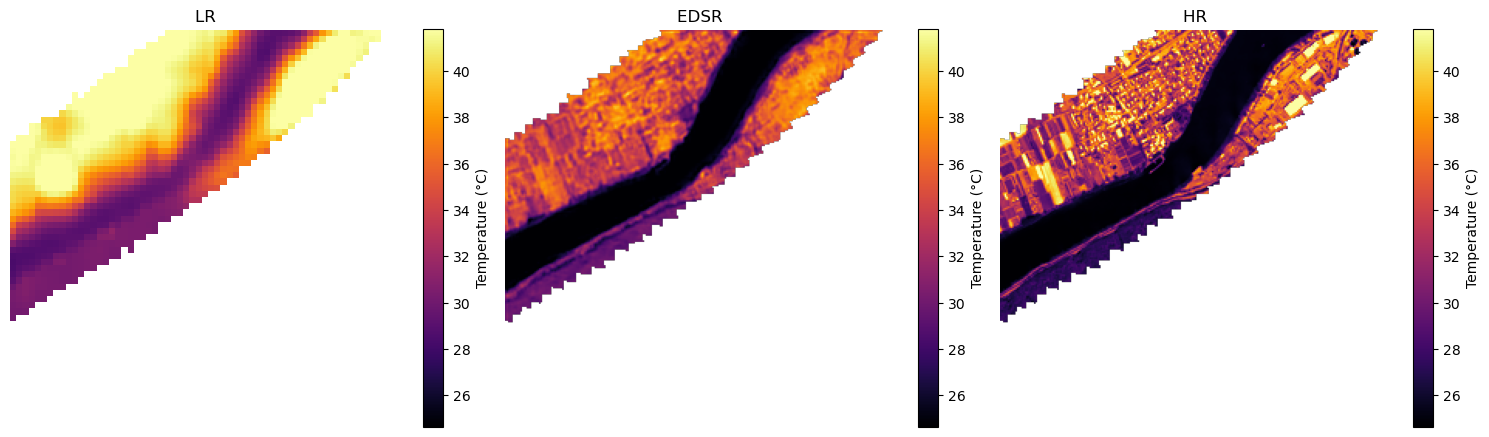

In [12]:
# Plot 
vmin, vmax = np.nanpercentile(hr_final, [2, 98])

panels = [
    ("LR ",       lr_final),
    ("EDSR ",   sr_final),
    ("HR ",      hr_final),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(img, cmap=CMAP, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Temperature (°C)")

plt.tight_layout()
plt.show()

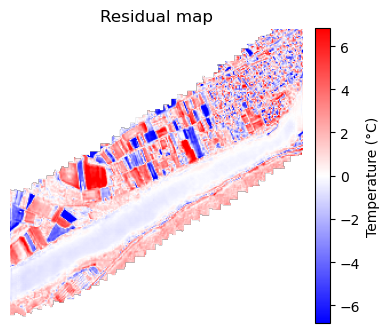

In [8]:
residual = sr_final - hr_final

v = np.percentile(np.abs(residual[~np.isnan(residual)]), 98)

plt.figure(figsize=(4, 4))
plt.title("Residual map")
plt.imshow(residual, cmap="bwr", vmin=-v, vmax=v)
plt.colorbar(fraction=0.046, pad=0.04, label="Temperature (°C)")
plt.axis("off")
plt.tight_layout()
plt.show()

### swinir

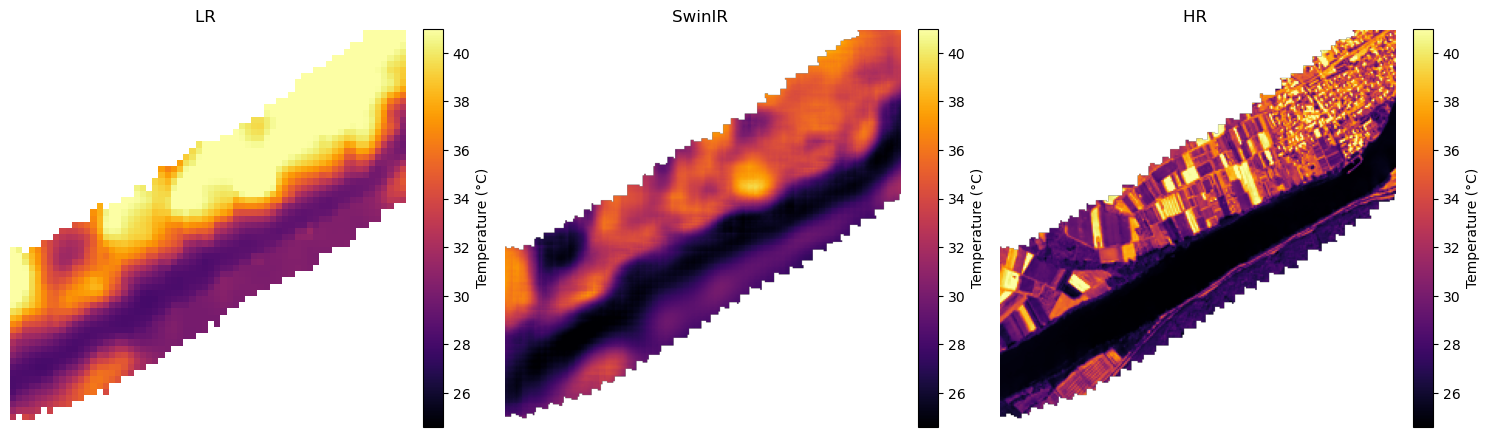

In [8]:
# Plot 
vmin, vmax = np.nanpercentile(hr_final, [2, 98])

panels = [
    ("LR ",       lr_final),
    ("SwinIR ",   sr_final),
    ("HR ",      hr_final),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(img, cmap=CMAP, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Temperature (°C)")

plt.tight_layout()
plt.show()

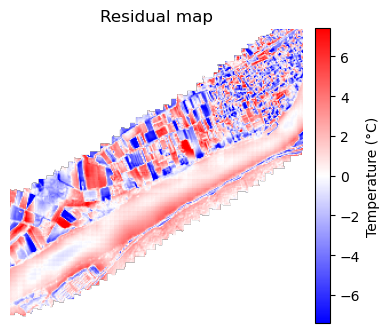

In [9]:
residual = sr_final - hr_final

v = np.percentile(np.abs(residual[~np.isnan(residual)]), 98)

plt.figure(figsize=(4, 4))
plt.title("Residual map")
plt.imshow(residual, cmap="bwr", vmin=-v, vmax=v)
plt.colorbar(fraction=0.046, pad=0.04, label="Temperature (°C)")
plt.axis("off")
plt.tight_layout()
plt.show()

### HAT

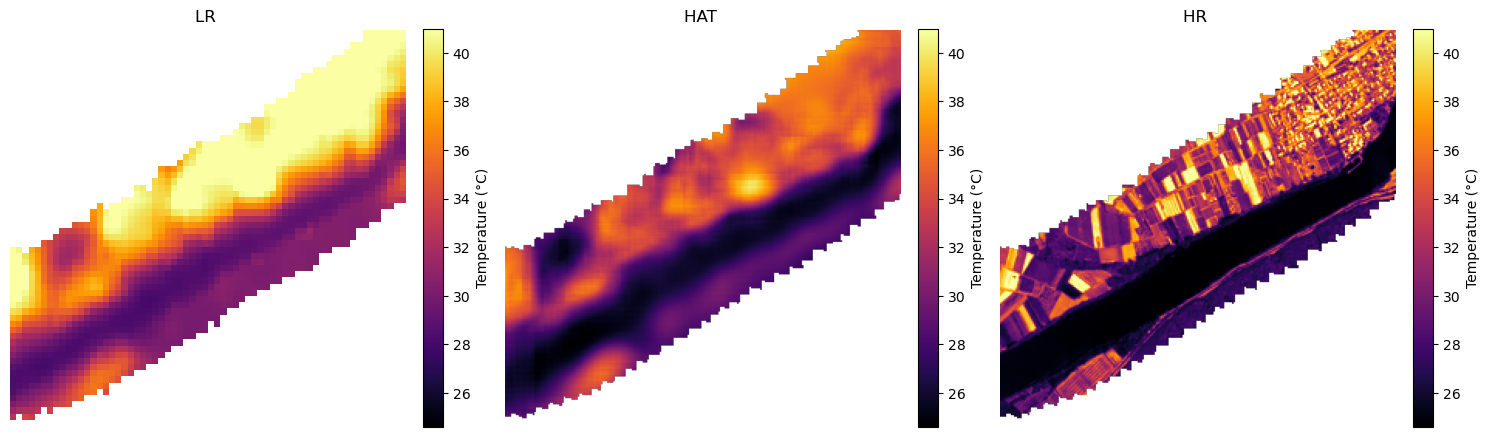

In [7]:
# Plot 
vmin, vmax = np.nanpercentile(hr_final, [2, 98])

panels = [
    ("LR ",       lr_final),
    ("HAT ",   sr_final),
    ("HR ",      hr_final),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(img, cmap=CMAP, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Temperature (°C)")

plt.tight_layout()
plt.show()

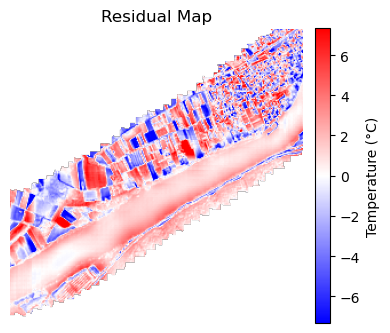

In [8]:
residual = sr_final - hr_final

v = np.percentile(np.abs(residual[~np.isnan(residual)]), 98)

plt.figure(figsize=(4, 4))
plt.title("Residual Map")
plt.imshow(residual, cmap="bwr", vmin=-v, vmax=v)
plt.colorbar(fraction=0.046, pad=0.04, label="Temperature (°C)")
plt.axis("off")
plt.tight_layout()
plt.show()

### RealESRGAN

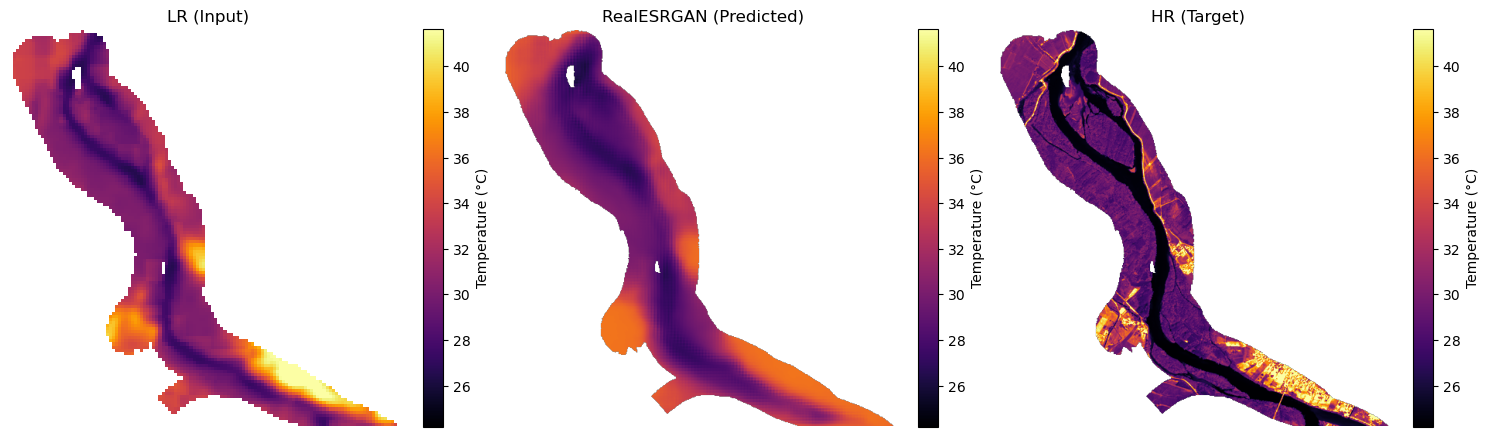

In [ ]:
# Plot 
vmin, vmax = np.nanpercentile(hr_final, [2, 98])

panels = [
    ("LR ",       lr_final),
    ("RealESRGAN ",   sr_final),
    ("HR ",      hr_final),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(img, cmap=CMAP, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Temperature (°C)")

plt.tight_layout()
plt.show()

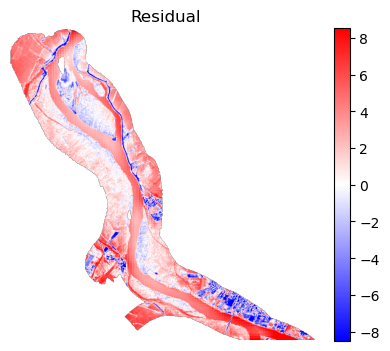

In [ ]:
residual = sr_final - hr_final

v = np.percentile(np.abs(residual[~np.isnan(residual)]), 98)

plt.figure(figsize=(4, 4))
plt.title("Residual Map")
plt.imshow(residual, cmap="bwr", vmin=-v, vmax=v)
plt.colorbar(fraction=0.046, pad=0.04, label="Temperature (°C)")
plt.axis("off")
plt.tight_layout()
plt.show()

## MISC

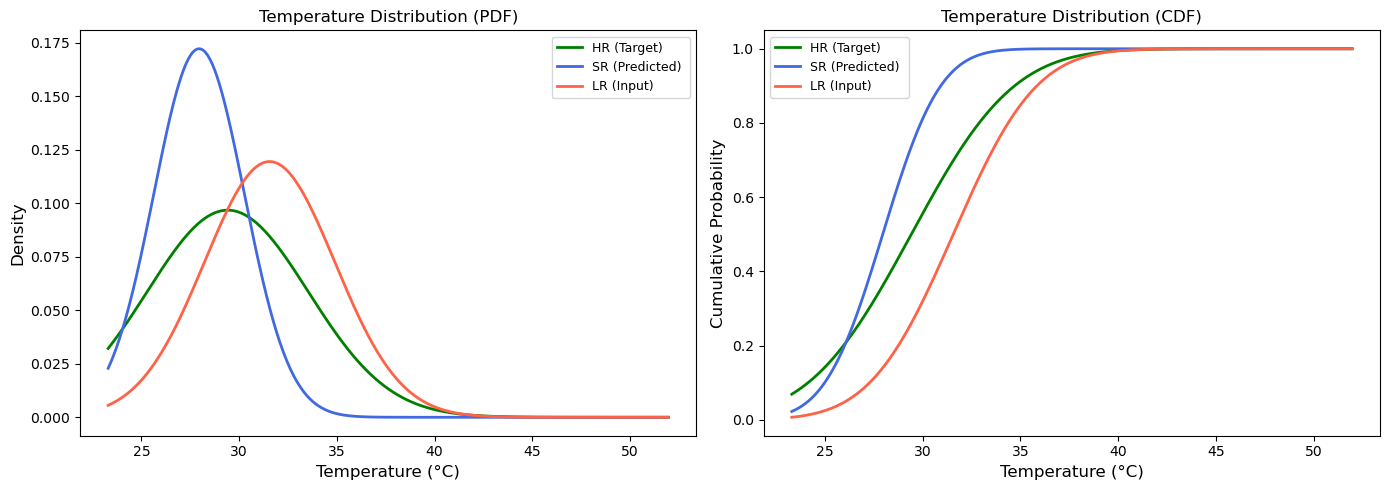

In [21]:
from scipy import stats

hr_valid = hr_final[mask_hr].flatten()
sr_valid = sr_final[mask_sr].flatten()
lr_valid = lr_final[mask_lr].flatten()

palette = {"HR": "green", "SR": "royalblue", "LR": "tomato"}
data    = {"HR": hr_valid, "SR": sr_valid, "LR": lr_valid}
labels  = {"HR": "HR (Target)", "SR": "SR (Predicted)", "LR": "LR (Input)"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, plot_type in zip(axes, ["PDF", "CDF"]):
    x_min = min(vals.min() for vals in data.values())
    x_max = max(vals.max() for vals in data.values())
    x = np.linspace(x_min, x_max, 500)  # shared range

    for key, vals in data.items():
        mu, std = stats.norm.fit(vals)
        y = stats.norm.pdf(x, mu, std) if plot_type == "PDF" else stats.norm.cdf(x, mu, std)
        ax.plot(x, y, color=palette[key], lw=2, label=f"{labels[key]} ")
# (μ={mu:.1f}°C, σ={std:.1f}°C)
    ax.set_xlabel("Temperature (°C)", fontsize=12)
    ax.set_ylabel("Density" if plot_type == "PDF" else "Cumulative Probability", fontsize=12)
    ax.set_title(f"Temperature Distribution ({plot_type})", fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

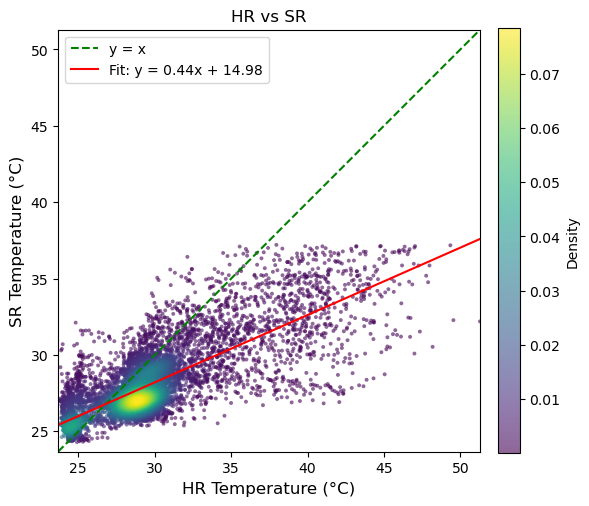

In [25]:
from scipy.stats import gaussian_kde
# ── 2. SR vs HR Scatter with Density Coloring ─────────────────────────────────
num_samples = min(len(hr_valid), 10000)
idx_sample  = np.random.choice(len(hr_valid), num_samples, replace=False)
hr_sample   = hr_valid[idx_sample]
sr_sample   = sr_valid[idx_sample]

# Shared range
t_min = min(hr_sample.min(), sr_sample.min())
t_max = max(hr_sample.max(), sr_sample.max())

# Density estimate per point (for color)
xy      = np.vstack([hr_sample, sr_sample])
density = gaussian_kde(xy)(xy)
order   = density.argsort()  # draw dense points on top

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(
    hr_sample[order], sr_sample[order],
    c=density[order], cmap="viridis",
    s=8, alpha=0.6, linewidths=0
)
fig.colorbar(sc, ax=ax, label="Density", fraction=0.046, pad=0.04)

# y=x ideal line
ax.plot([t_min, t_max], [t_min, t_max], "g--", lw=1.5, label="y = x")

# Regression line
coeffs = np.polyfit(hr_sample, sr_sample, 1)
ax.plot(
    [t_min, t_max], np.polyval(coeffs, [t_min, t_max]),
    "r-", lw=1.5, label=f"Fit: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}"
)

ax.set_xlim(t_min, t_max)
ax.set_ylim(t_min, t_max)
ax.set_aspect("equal")
ax.set_xlabel("HR Temperature (°C)", fontsize=12)
ax.set_ylabel("SR Temperature (°C)", fontsize=12)
ax.set_title("HR vs SR", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [33]:
import torch.nn.functional as F

def psnr_on_valid(pred, target, valid_mask, data_range):
    err = pred[valid_mask] - target[valid_mask]
    mse = np.mean(err ** 2)
    if mse <= 1e-12:
        return float("inf")
    return 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)

def mae_on_valid(pred, target, valid_mask):
    return float(np.mean(np.abs(pred[valid_mask] - target[valid_mask])))

# Bicubic upsample LR -> HR size
with torch.no_grad():
    bicubic_t = F.interpolate(
        lr_t.unsqueeze(0).to(device),     # (1,1,h,w)
        size=hr_t.shape[-2:],             # HR shape
        mode="bicubic",
        align_corners=False
    )

# Denormalize to Celsius
bicubic_np = model.denormalize(bicubic_t).cpu().numpy().squeeze()

# Valid mask from your existing pipeline
valid = mask_bool

# Same range as model metrics
data_range = float(model.DATA_RANGE)

# Compare SR vs Bicubic on valid pixels only
psnr_sr = psnr_on_valid(sr_np, hr_np, valid, data_range)
psnr_bi = psnr_on_valid(bicubic_np, hr_np, valid, data_range)
mae_sr = mae_on_valid(sr_np, hr_np, valid)
mae_bi = mae_on_valid(bicubic_np, hr_np, valid)

print(f"PSNR SR      : {psnr_sr:.3f} dB")
print(f"PSNR Bicubic : {psnr_bi:.3f} dB")
print(f"Delta PSNR   : {psnr_sr - psnr_bi:+.3f} dB")
print(f"MAE SR       : {mae_sr:.3f} C")
print(f"MAE Bicubic  : {mae_bi:.3f} C")
print(f"Delta MAE    : {mae_sr - mae_bi:+.3f} C  (negative is better)")

PSNR SR      : 18.763 dB
PSNR Bicubic : 11.554 dB
Delta PSNR   : +7.209 dB
MAE SR       : 1.904 C
MAE Bicubic  : 5.323 C
Delta MAE    : -3.419 C  (negative is better)


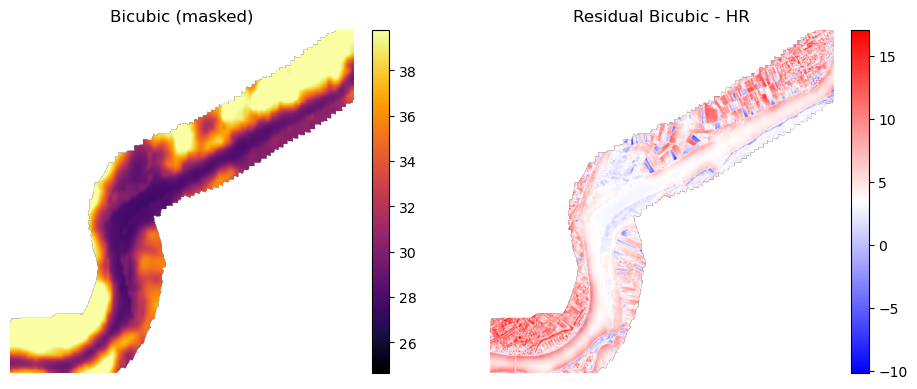

In [34]:
residual_bi = np.where(valid, bicubic_np - hr_np, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(np.where(valid, bicubic_np, np.nan), cmap="inferno", vmin=vmin, vmax=vmax)
ax[0].set_title("Bicubic (masked)")
ax[0].axis("off")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(residual_bi, cmap="bwr")
ax[1].set_title("Residual Bicubic - HR")
ax[1].axis("off")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

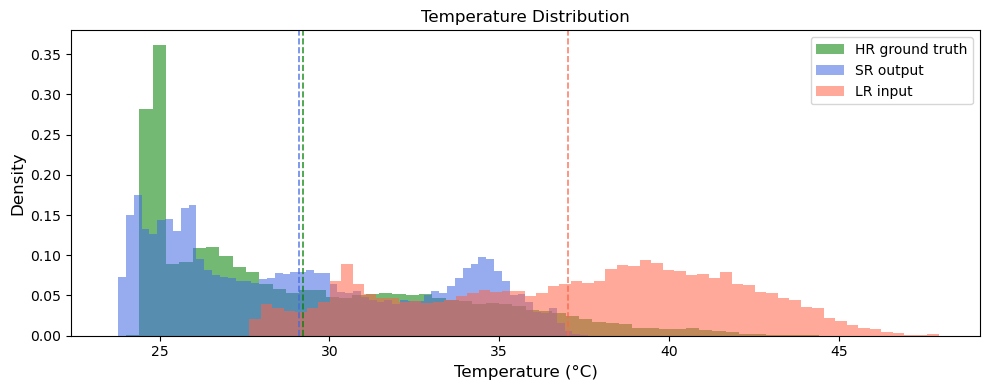

In [15]:
# A blurry model will have SR std << HR std — distribution too narrow
# A good model will have SR std ≈ HR std and similar shape
hr_valid = hr_final[mask_bool].flatten()
sr_valid = sr_final[mask_bool].flatten()
# lr_valid = lr_final[lr_mask].flatten()
lr_valid = lr_np.flatten()  # no masking needed
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hr_valid, bins=60, alpha=0.55, color="green",     label="HR ground truth", density=True)
ax.hist(sr_valid, bins=60, alpha=0.55, color="royalblue", label="SR output",       density=True)
ax.hist(lr_valid, bins=60, alpha=0.55, color="tomato",    label="LR input",        density=True)
 
# Vertical mean lines
for val, color in [(hr_valid.mean(), "green"),
                   (sr_valid.mean(), "royalblue"),
                   (lr_valid.mean(), "tomato")]:
    ax.axvline(val, color=color, linestyle="--", lw=1.2, alpha=0.8)
 
ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Temperature Distribution", fontsize=12)
ax.legend(fontsize=10)
 
# Std annotation — key diagnostic for blurriness
# textstr = (f"HR  std: {hr_valid.std():.3f} °C\n"
#            f"SR  std: {sr_valid.std():.3f} °C\n"
#            f"LR  std: {lr_valid.std():.3f} °C")
# ax.text(0.98, 0.97, textstr, transform=ax.transAxes,
#         fontsize=9, va="top", ha="right",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
plt.tight_layout()
plt.show()

BRC 2023:
SR  range : 21.55 – 40.31 °C
HR  range : 1.22 – 131.17 °C

BRC 2022:
SR  range : 22.44 – 40.97 °C
HR  range : 20.03 – 60.39 °C

Shared vmin/vmax : 21.26 / 42.71
Residual limits  : -10.68 / 10.68


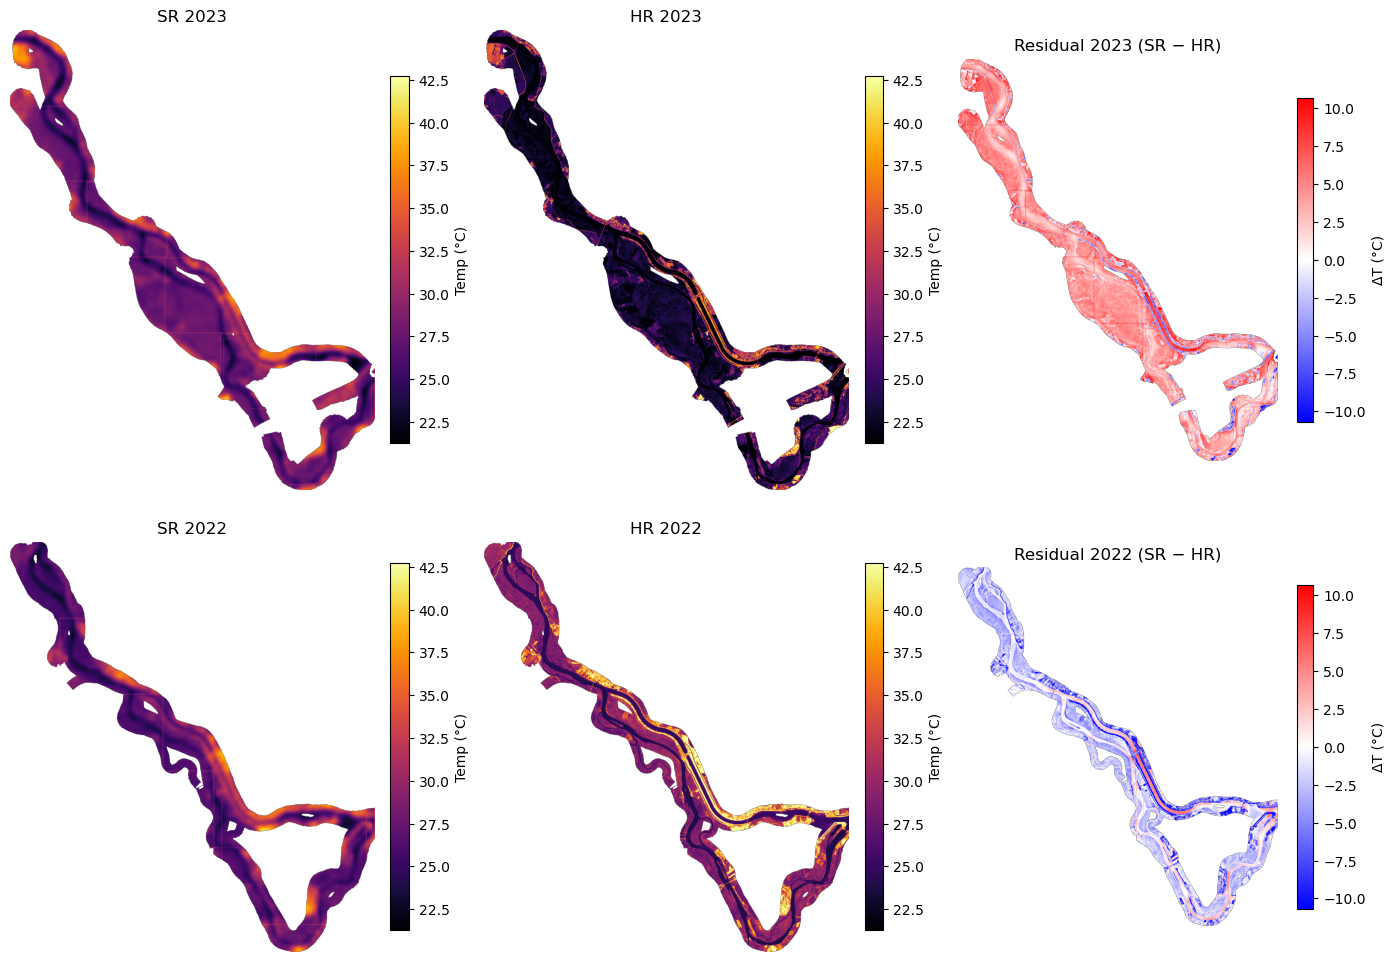

In [18]:
# Paths
sr_path1 = "results/SR_images/SR_BRC_2023.tif"
sr_path2 = "results/SR_images/SR_BRC_2022.tif"
hr_path1 = "results/SR_images/HR_reassembled_BRC_2023.tif"
hr_path2 = "results/SR_images/HR_reassembled_BRC_2022.tif"

# Helper function
def load_raster(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nodata = src.nodata
    return np.where(arr == nodata, np.nan, arr)

# Load data
sr1 = load_raster(sr_path1)
hr1 = load_raster(hr_path1)
sr2 = load_raster(sr_path2)
hr2 = load_raster(hr_path2)

# Residuals (safe masking)
residual1 = np.where(np.isnan(sr1) | np.isnan(hr1), np.nan, sr1 - hr1)
residual2 = np.where(np.isnan(sr2) | np.isnan(hr2), np.nan, sr2 - hr2)

# Shared temperature scale (better comparison)
combined_hr = np.concatenate([hr1.flatten(), hr2.flatten()])
combined_hr = combined_hr[~np.isnan(combined_hr)]

vmin = np.percentile(combined_hr, 2)
vmax = np.percentile(combined_hr, 98)

# Dynamic residual scaling (symmetric)
res_all = np.concatenate([residual1.flatten(), residual2.flatten()])
res_all = res_all[~np.isnan(res_all)]
lim = np.percentile(np.abs(res_all), 98)

vmin_res, vmax_res = -lim, lim

# Print stats
print("BRC 2023:")
print(f"SR  range : {np.nanmin(sr1):.2f} – {np.nanmax(sr1):.2f} °C")
print(f"HR  range : {np.nanmin(hr1):.2f} – {np.nanmax(hr1):.2f} °C")

print("\nBRC 2022:")
print(f"SR  range : {np.nanmin(sr2):.2f} – {np.nanmax(sr2):.2f} °C")
print(f"HR  range : {np.nanmin(hr2):.2f} – {np.nanmax(hr2):.2f} °C")

print(f"\nShared vmin/vmax : {vmin:.2f} / {vmax:.2f}")
print(f"Residual limits  : {vmin_res:.2f} / {vmax_res:.2f}")

# Plot
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# ---- 2023 ----
im0 = axes[0, 0].imshow(sr1, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0, 0].set_title("SR 2023")
axes[0, 0].axis("off")
plt.colorbar(im0, ax=axes[0, 0], label="Temp (°C)", fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(hr1, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("HR 2023")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], label="Temp (°C)", fraction=0.046, pad=0.04)

im2 = axes[0, 2].imshow(residual1, cmap="bwr", vmin=vmin_res, vmax=vmax_res)
axes[0, 2].set_title("Residual 2023 (SR − HR)")
axes[0, 2].axis("off")
plt.colorbar(im2, ax=axes[0, 2], label="ΔT (°C)", shrink=0.7)

# ---- 2022 ----
im3 = axes[1, 0].imshow(sr2, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("SR 2022")
axes[1, 0].axis("off")
plt.colorbar(im3, ax=axes[1, 0], label="Temp (°C)", fraction=0.046, pad=0.04)

im4 = axes[1, 1].imshow(hr2, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1, 1].set_title("HR 2022")
axes[1, 1].axis("off")
plt.colorbar(im4, ax=axes[1, 1], label="Temp (°C)", fraction=0.046, pad=0.04)

im5 = axes[1, 2].imshow(residual2, cmap="bwr", vmin=vmin_res, vmax=vmax_res)
axes[1, 2].set_title("Residual 2022 (SR − HR)")
axes[1, 2].axis("off")
plt.colorbar(im5, ax=axes[1, 2], label="ΔT (°C)", shrink=0.7)

plt.tight_layout()
plt.show()

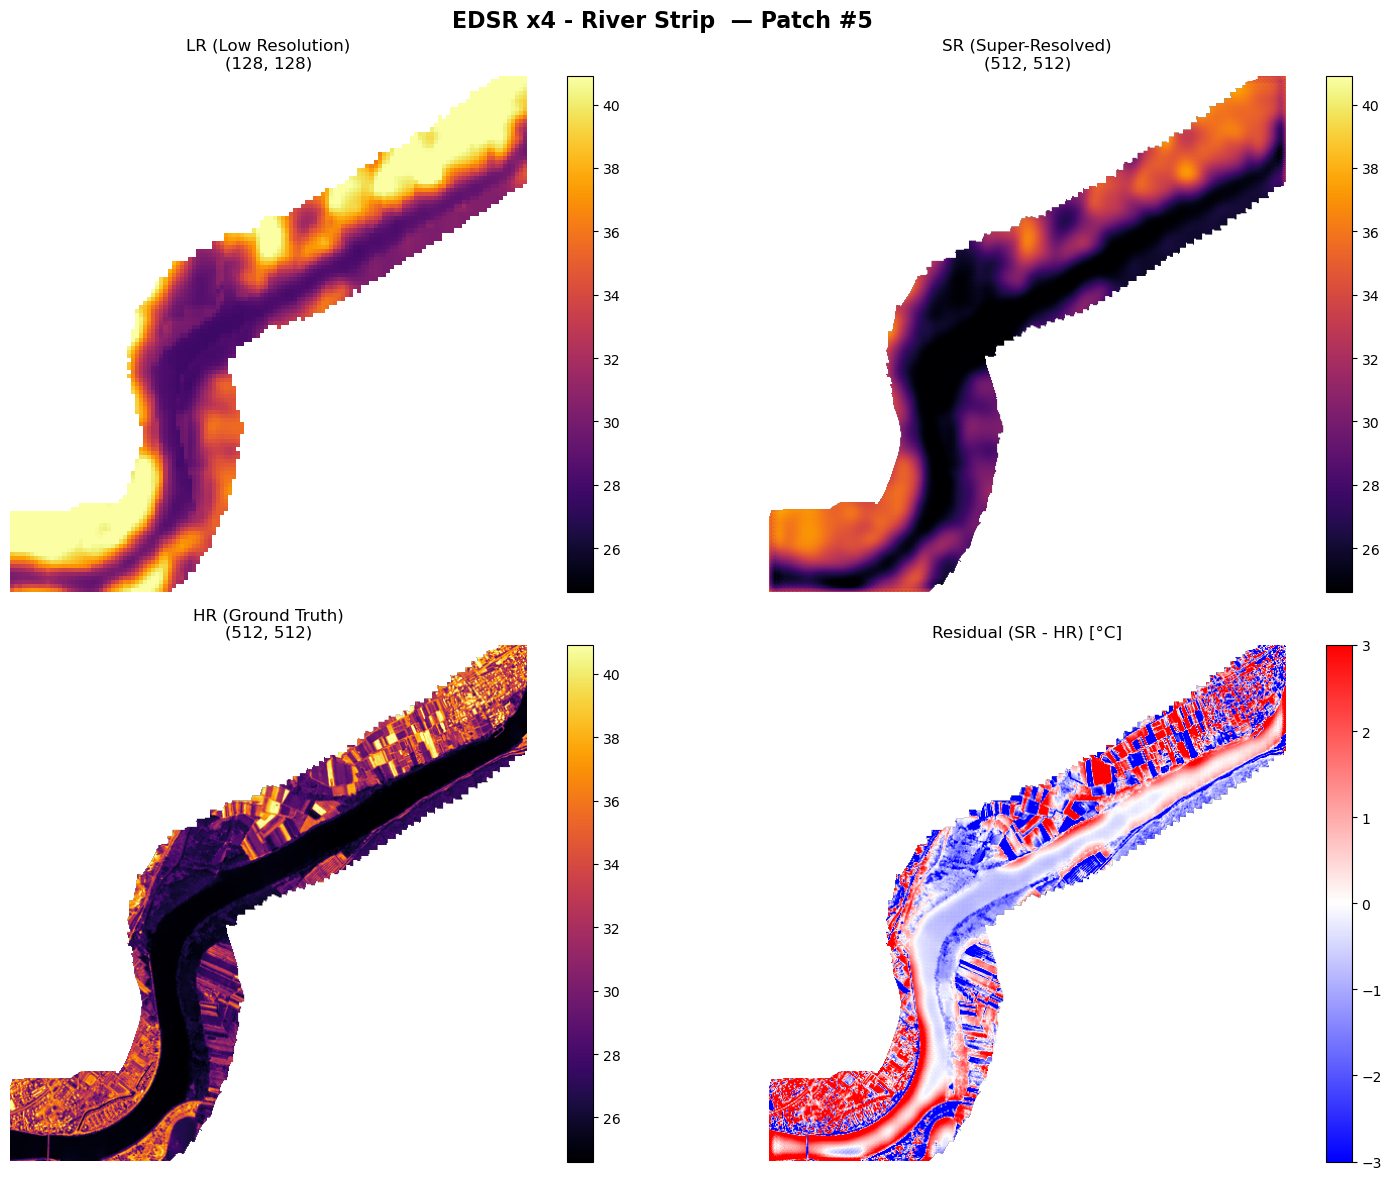

In [23]:
idx = 5   # change this to explore different patches

lr_t, hr_t, mask_t = ds[idx]

lr_input = lr_t.unsqueeze(0).to(device)

with torch.no_grad():
    sr_t = model(lr_input)

# Now plot with masking
plot_tir_sr_masked(
    lr=lr_t,
    sr=sr_t,
    hr=hr_t,
    mask=mask_t,
    mean=model.hparams.mean,
    std=model.hparams.std,
    title="EDSR x4 - River Strip ",
    idx=idx
)

## MODEL DEV

In [1]:
import numpy as np
from pathlib import Path

PATCH_DIR = Path(
    "/share/home/e2406751/Superresolution-TIR/data/processed/patches/train/AUX"
)

files = sorted(PATCH_DIR.glob("*.npy"))

print(f"Found {len(files)} AUX patches\n")

# --------------------------------------------------
# CHECK FIRST 5 PATCHES
# --------------------------------------------------
for f in files[:5]:

    arr = np.load(f)

    print("=" * 60)
    print(f"FILE: {f.name}")

    print("Shape:", arr.shape)
    print("Dtype:", arr.dtype)

    channel_names = [
        "BLUE",
        "GREEN",
        "RED",
        "NIR",
        "SWIR1",
        "NDVI",
        "NDWI",
        "NDMI",
        "LULC",
        "DEM"
    ]

    for i, name in enumerate(channel_names):

        band = arr[i]

        print(f"\n{name}")

        print("  min :", np.min(band))
        print("  max :", np.max(band))
        print("  mean:", np.mean(band))

        print(
            "  nan%:",
            np.isnan(band).sum() / band.size * 100
        )

Found 368 AUX patches

FILE: BAS_2025_b0_r0_c1024.npy
Shape: (10, 64, 64)
Dtype: float32

BLUE
  min : 0.0109
  max : 0.2339
  mean: 0.06455374
  nan%: 0.0

GREEN
  min : 0.0307
  max : 0.2505
  mean: 0.09656845
  nan%: 0.0

RED
  min : 0.0192
  max : 0.2888
  mean: 0.1123927
  nan%: 0.0

NIR
  min : 0.1565
  max : 0.4637
  mean: 0.29880223
  nan%: 0.0

SWIR1
  min : 0.1768
  max : 0.4651
  mean: 0.3178795
  nan%: 0.0

NDVI
  min : 0.054023422
  max : 0.88947624
  mean: 0.4648239
  nan%: 0.0

NDWI
  min : -0.8186651
  max : -0.10035175
  mean: -0.5128569
  nan%: 0.0

NDMI
  min : -0.28838083
  max : 0.36722204
  mean: -0.023413153
  nan%: 0.0

LULC
  min : 10.0
  max : 50.0
  mean: 24.07959
  nan%: 0.0

DEM
  min : 0.07049621
  max : 0.11036955
  mean: 0.08936613
  nan%: 0.0
FILE: BAS_2025_b0_r0_c1152.npy
Shape: (10, 64, 64)
Dtype: float32

BLUE
  min : 0.0131
  max : 0.3232
  mean: 0.05471443
  nan%: 0.0

GREEN
  min : 0.0327
  max : 0.3374
  mean: 0.087028906
  nan%: 0.0

RED
  min :

In [3]:
import torch
ckpt = torch.load("/share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth", map_location="cpu")
state_dict = ckpt.get("params", ckpt)

print("All checkpoint keys:")
for k in sorted(state_dict.keys()):
    print(f"  {k:50s}  {tuple(state_dict[k].shape)}")

All checkpoint keys:
  conv_after_body.bias                                (180,)
  conv_after_body.weight                              (180, 180, 3, 3)
  conv_before_upsample.0.bias                         (64,)
  conv_before_upsample.0.weight                       (64, 180, 3, 3)
  conv_first.bias                                     (180,)
  conv_first.weight                                   (180, 3, 3, 3)
  conv_last.bias                                      (3,)
  conv_last.weight                                    (3, 64, 3, 3)
  layers.0.conv.bias                                  (180,)
  layers.0.conv.weight                                (180, 180, 3, 3)
  layers.0.residual_group.blocks.0.attn.proj.bias     (180,)
  layers.0.residual_group.blocks.0.attn.proj.weight   (180, 180)
  layers.0.residual_group.blocks.0.attn.qkv.bias      (540,)
  layers.0.residual_group.blocks.0.attn.qkv.weight    (540, 180)
  layers.0.residual_group.blocks.0.attn.relative_position_bias_table  (225, 

/tmp/ipykernel_786053/160128910.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("/share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classi

LR shape:  (64, 64)
HR shape:  (256, 256)
AUX shape: (23, 64, 64)

NDWI range: -0.852 to 0.750
NDVI range: -0.526 to 0.929
LULC water fraction: 0.161


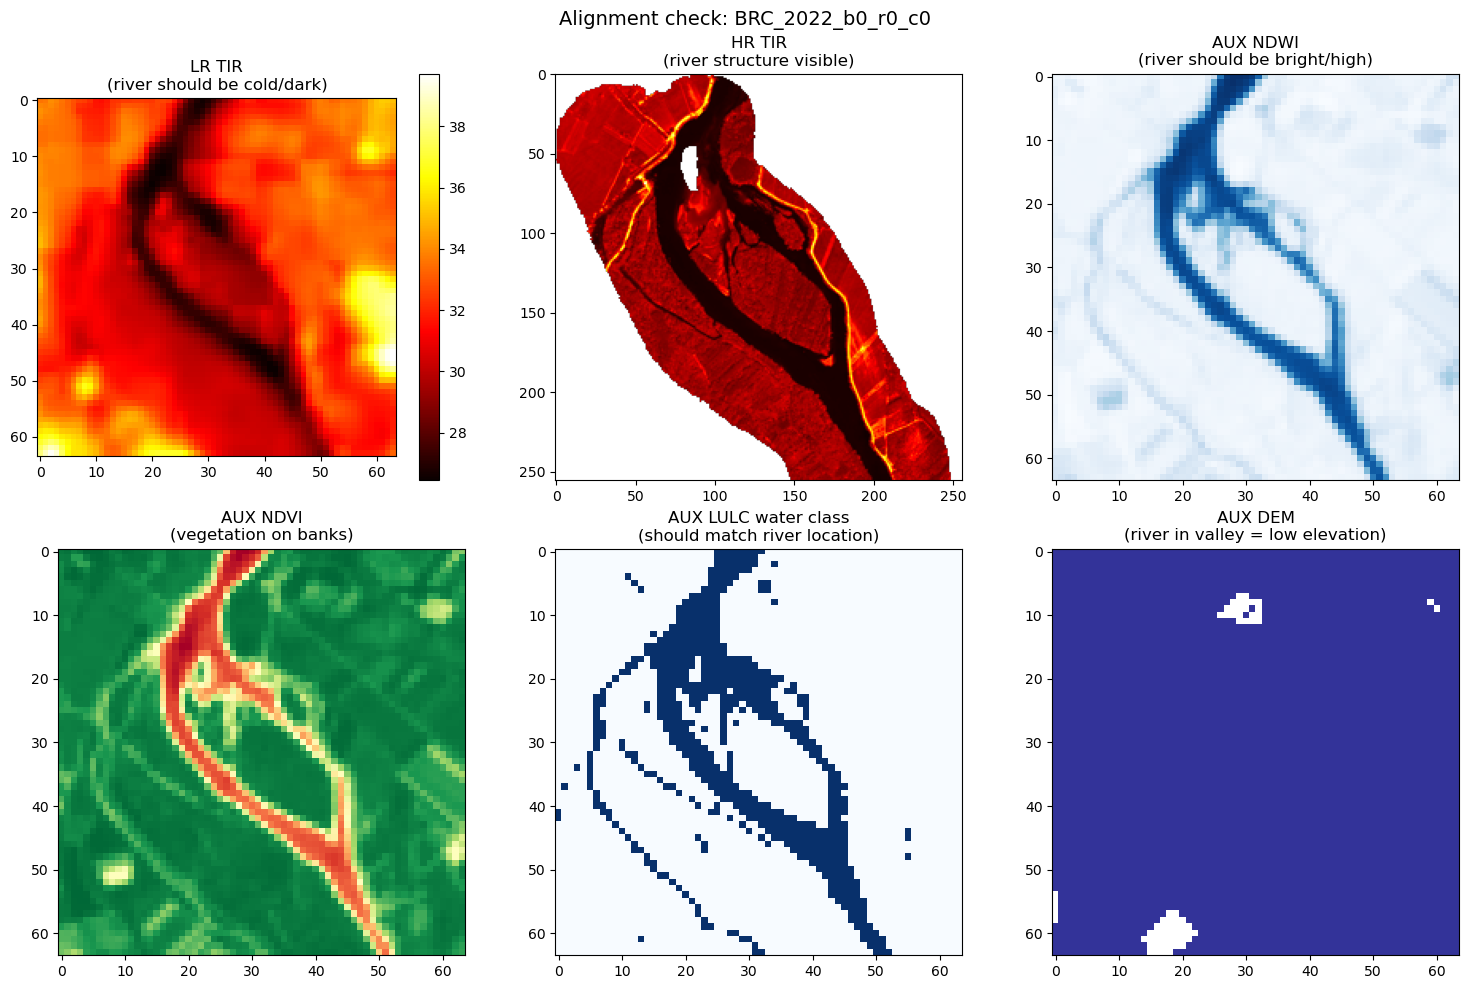


Alignment is CORRECT if:
  - NDWI is high where LR/HR shows cold river
  - LULC water class matches river location
  - DEM is low where river is


In [6]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds
from pyproj import Transformer
import json
from pathlib import Path
import matplotlib.pyplot as plt

PATCHES_DIR = Path("/share/home/e2406751/Superresolution-TIR/data/processed/patches")
AUX_DIR     = Path("/share/home/e2406751/Superresolution-TIR/data/AUX/auxiliary")
METADATA_PATH = PATCHES_DIR / "metadata.json"

with open(METADATA_PATH) as f:
    metadata = json.load(f)

# pick one tile with water — BRC has river
tile_name = "BRC_2022_b0_r0_c0"
info = metadata[tile_name]
split = info["split"]

# load patches
lr  = np.load(PATCHES_DIR / split / "LR"  / f"{tile_name}.npy")
hr  = np.load(PATCHES_DIR / split / "HR"  / f"{tile_name}.npy")
aux = np.load(PATCHES_DIR / split / "AUX" / f"{tile_name}.npy")

print(f"LR shape:  {lr.shape}")
print(f"HR shape:  {hr.shape}")
print(f"AUX shape: {aux.shape}")

# aux channels
# 0-4: spectral (B,G,R,NIR,SWIR)
# 5:   NDVI
# 6:   NDWI   ← water index, should show river
# 7:   NDMI
# 8-21: LULC one-hot
# 22:  DEM

ndwi = aux[6]   # water index — river should be bright
ndvi = aux[5]   # vegetation — banks should be bright
lulc_water = aux[13]  # LULC class 6 = water body

print(f"\nNDWI range: {ndwi.min():.3f} to {ndwi.max():.3f}")
print(f"NDVI range: {ndvi.min():.3f} to {ndvi.max():.3f}")
print(f"LULC water fraction: {lulc_water.mean():.3f}")

# plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(lr, cmap="hot")
axes[0, 0].set_title("LR TIR\n(river should be cold/dark)")
axes[0, 0].colorbar = plt.colorbar(axes[0, 0].images[0], ax=axes[0, 0])

axes[0, 1].imshow(hr, cmap="hot")
axes[0, 1].set_title("HR TIR\n(river structure visible)")

axes[0, 2].imshow(ndwi, cmap="Blues")
axes[0, 2].set_title("AUX NDWI\n(river should be bright/high)")

axes[1, 0].imshow(ndvi, cmap="RdYlGn")
axes[1, 0].set_title("AUX NDVI\n(vegetation on banks)")

axes[1, 1].imshow(lulc_water, cmap="Blues")
axes[1, 1].set_title("AUX LULC water class\n(should match river location)")

axes[1, 2].imshow(aux[19], cmap="terrain")
axes[1, 2].set_title("AUX DEM\n(river in valley = low elevation)")

plt.suptitle(f"Alignment check: {tile_name}", fontsize=14)
plt.tight_layout()
plt.show()

print("\nAlignment is CORRECT if:")
print("  - NDWI is high where LR/HR shows cold river")
print("  - LULC water class matches river location")
print("  - DEM is low where river is")

In [2]:
import sys
from pathlib import Path

BASE = Path("/share/home/e2406751/Superresolution-TIR")

sys.path.append(str(BASE))

from scripts.utils.dataset import SRDataset
from pathlib import Path

BASE = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR = BASE / "data/processed/patches"

ds = SRDataset(
    split="train",
    patches_dir=PATCHES_DIR,
    stats_path=PATCHES_DIR / "stats.json",
    metadata_path=PATCHES_DIR / "metadata.json",
    use_aux=True,
    use_water_mask=True,
    aux_dir=str(PATCHES_DIR / "train" / "AUX"),
    repeat_channels=False,
    transform=None,
    time_mode="both",      # try: none/date/time/both
)

sample = ds[0]

print("fname:", sample["fname"])
print("cond:", sample["cond"])
print("cond shape:", sample["cond"].shape)

if "aux" in sample:
    print("aux shape:", sample["aux"].shape)

print("lr shape:", sample["lr"].shape)
print("hr shape:", sample["hr"].shape)

fname: BAS_2025_b0_r0_c1024.npy
cond: tensor([0.0000, 0.4444])
cond shape: torch.Size([2])
aux shape: torch.Size([20, 64, 64])
lr shape: torch.Size([1, 64, 64])
hr shape: torch.Size([1, 256, 256])


In [1]:
import sys
from pathlib import Path
import torch

BASE = Path("/share/home/e2406751/Superresolution-TIR")
sys.path.append(str(BASE))

from scripts.training.train import build_model, load_config
from scripts.utils.dataset import SRDataset
import json

PATCHES_DIR = BASE / "data/processed/patches"
STATS_PATH = PATCHES_DIR / "stats.json"
METADATA_PATH = PATCHES_DIR / "metadata.json"
CONFIGS_DIR = BASE / "configs"

with open(STATS_PATH) as f:
    stats = json.load(f)

cfg = load_config("swinir")

ds = SRDataset(
    split="train",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    metadata_path=METADATA_PATH,
    use_aux=True,
    aux_dir=str(PATCHES_DIR / "train" / "AUX"),
    repeat_channels=False,
    time_mode="both"
)

sample = ds[0]

model = build_model(
    model_name="swinir",
    cfg=cfg,
    stats=stats,
    args=type("Args", (), {
        "lr": 1e-4,
        "adaptation_strategy": "projection",
        "lambda_grad": 0.0,
        "lambda_water": 0.0,
        "time_mode": "both" 
    })(),
    aux_chans=sample["aux"].shape[0]
)

model = model.cuda().eval()

/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[INFO] Loaded 550 pretrained weights


In [2]:
# DO NOT DELETE THIS CHUNK
import rasterio
import numpy as np
from pathlib import Path

AUX_DIR = Path("/share/home/e2406751/Superresolution-TIR/data/AUX/auxiliary")

stats = {}

for tif_path in AUX_DIR.glob("*_aux.tif"):

    campaign = tif_path.stem.replace("_aux", "")

    with rasterio.open(tif_path) as src:
        dem = src.read(9).astype(np.float32)  # last band = DEM
        dem = dem[np.isfinite(dem)]

        p2 = np.percentile(dem, 2)
        p98 = np.percentile(dem, 98)

        stats[campaign] = {"p2": float(p2), "p98": float(p98)}

print(stats)

import json

with open("dem_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

{'BRC_2023': {'p2': 204.21881408691405, 'p98': 634.7589892578126}, 'DZM_2023': {'p2': 37.28562545776367, 'p98': 313.6252087402344}, 'DZM_2014': {'p2': 36.505706024169925, 'p98': 119.18166809082032}, 'BRC_2022': {'p2': 204.23016357421875, 'p98': 636.0178710937498}, 'PDR_2014': {'p2': 131.7100067138672, 'p98': 382.94304687499994}, 'DZM_2019': {'p2': 43.71656036376953, 'p98': 120.82474121093747}, 'HAUT_2025': {'p2': 206.04987518310546, 'p98': 1201.226364746094}, 'PDR_2013': {'p2': 131.77515899658204, 'p98': 382.72632751464846}, 'BAS_2025': {'p2': 39.22609329223633, 'p98': 531.2723486328123}, 'DZM_2013': {'p2': 34.058629455566404, 'p98': 277.9038055419922}, 'PDR_2023': {'p2': 136.68359375, 'p98': 424.2940673828125}}


In [7]:
## PATCH CHEKER esp lulc one-hot validity
import numpy as np
from pathlib import Path

aux_dir = Path("/share/home/e2406751/Superresolution-TIR/data/processed/patches/train/AUX")
files = list(aux_dir.glob("*.npy"))[:20]
COSIA_CLASSES = [1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 0]

for f in files:
    x = np.load(f)

    lulc = x[8:21]  # 11 LULC channels
    unique_classes = np.unique(COSIA_CLASSES)

    print("classes found:", unique_classes)

    expected = {1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 13, 14, 15, 0}

    print("unknown classes:", set(unique_classes) - expected)
    # convert one-hot → class index per pixel
    lulc_class_map = lulc.argmax(axis=0)
    print("unique LULC classes in tile:", np.unique(lulc_class_map))

    # sanity check: each pixel should belong to exactly 1 class → sum should be 1
    pixel_sum = lulc.sum(axis=0)
    print(f.name)
    print("unique pixel sums:", np.unique(pixel_sum))
    print("min sum:", pixel_sum.min(), "max sum:", pixel_sum.max())

    # sanity check: max activation per pixel should be 1 (one-hot) or 0 (no class)
    max_per_pixel = lulc.max(axis=0)
    print("max channel activation (should be 1):", np.unique(max_per_pixel))

    print("---")

classes found: [ 0  1  2  3  4  5  6  8  9 10 12 13 14 15]
unknown classes: set()
unique LULC classes in tile: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
DZM_2014_b0_r768_c0.npy
unique pixel sums: [0. 1.]
min sum: 0.0 max sum: 1.0
max channel activation (should be 1): [0. 1.]
---
classes found: [ 0  1  2  3  4  5  6  8  9 10 12 13 14 15]
unknown classes: set()
unique LULC classes in tile: [ 0  1  2  3  4  5  6  7  8  9 10]
BAS_2025_b0_r0_c1024.npy
unique pixel sums: [1.]
min sum: 1.0 max sum: 1.0
max channel activation (should be 1): [1.]
---
classes found: [ 0  1  2  3  4  5  6  8  9 10 12 13 14 15]
unknown classes: set()
unique LULC classes in tile: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
BAS_2025_b5_r5120_c128.npy
unique pixel sums: [0. 1.]
min sum: 0.0 max sum: 1.0
max channel activation (should be 1): [0. 1.]
---
classes found: [ 0  1  2  3  4  5  6  8  9 10 12 13 14 15]
unknown classes: set()
unique LULC classes in tile: [ 0  1  2  4  5  6  7  8  9 10 11 12]
PDR_2013_b0_r512_c0.np

## spade checks

In [2]:
import torch
import torch.nn as nn
from basicsr.archs import swinir_arch
from torchinfo import summary  # <-- Import the summary function

# 1. Create your SwinIR model
model = swinir_arch.SwinIR(
    upscale=4,
    in_chans=3,
    img_size=48,
    embed_dim=180,
    depths=[6]*6,
    num_heads=[6]*6,
    window_size=8,
    upsampler="pixelshuffle",
    resi_connection="1conv",
    num_out_ch=3
)

# 2. Define the input size: (batch_size, channels, height, width)
# We'll use a batch size of 1, 3 channels, and 48x48 image size
input_size = (1, 3, 48, 48)

# 3. Print the summary with shapes and parameter counts
print("=== Model Structure and Output Shapes ===")
summary(model, input_size=input_size, depth=3, device="cpu")  # Set device to "cpu" or "cuda" as needed

=== Model Structure and Output Shapes ===


Layer (type:depth-idx)                                  Output Shape              Param #
SwinIR                                                  [1, 3, 192, 192]          --
├─Conv2d: 1-1                                           [1, 180, 48, 48]          5,040
├─PatchEmbed: 1-2                                       [1, 2304, 180]            --
│    └─LayerNorm: 2-1                                   [1, 2304, 180]            360
├─Dropout: 1-3                                          [1, 2304, 180]            --
├─ModuleList: 1-4                                       --                        --
│    └─RSTB: 2-2                                        [1, 2304, 180]            --
│    │    └─BasicLayer: 3-1                             [1, 2304, 180]            2,354,940
│    │    └─PatchUnEmbed: 3-2                           [1, 180, 48, 48]          --
│    │    └─Conv2d: 3-3                                 [1, 180, 48, 48]          291,780
│    │    └─PatchEmbed: 3-4                 

In [2]:
import torch

# 1. Load your checkpoint file
checkpoint_path = "/share/home/e2406751/Superresolution-TIR/data/pretrained/SwinIR_classical_x4.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

# 2. Check if the weights are nested (BasicSR often saves models under a 'params' key)
if "params" in checkpoint:
    state_dict = checkpoint["params"]
elif "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint

# 3. Print out every layer weight and its tensor shape
print(f"{'Layer Name':<60} | {'Weight Shape':<20}")
print("-" * 85)

for layer_name, weights in state_dict.items():
    # Convert shape to string for nice formatting
    shape_str = str(list(weights.shape))
    print(f"{layer_name:<60} | {shape_str:<20}")

Layer Name                                                   | Weight Shape        
-------------------------------------------------------------------------------------
conv_first.weight                                            | [180, 3, 3, 3]      
conv_first.bias                                              | [180]               
conv_after_body.weight                                       | [180, 180, 3, 3]    
conv_after_body.bias                                         | [180]               
conv_before_upsample.0.weight                                | [64, 180, 3, 3]     
conv_before_upsample.0.bias                                  | [64]                
upsample.0.weight                                            | [256, 64, 3, 3]     
upsample.0.bias                                              | [256]               
upsample.2.weight                                            | [256, 64, 3, 3]     
upsample.2.bias                                              | [256]      

/tmp/ipykernel_2139433/1799142611.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location="cpu")


In [1]:

import torch
from pathlib import Path
import sys

BASE          = Path("/share/home/e2406751/Superresolution-TIR")
sys.path.insert(0, str(BASE))


In [10]:
import importlib
import scripts.models.swinir_copy as m
importlib.reload(m)

from scripts.models.swinir_copy import SwinIRModule
# ==================== FORWARD PASS TEST ====================

# Create model with safe/recommended settings for testing
model = SwinIRModule(
    pretrained_path=None,           # None = no pretrained weights for test
    learning_rate=1e-4,
    img_size=48,
    embed_dim=180,                  # your SwinIR embed dim
    aux_chans=20,
    use_spade=True,
    freeze_backbone=False,          # False for shape test
    freeze_mode="none",
    # Normalization stats (can be dummy for shape test)
    hr_mean=[0.0],
    hr_std=[1.0],
    data_range=1.0,
    data_min=0.0,
)

# Put model in eval mode + move to CPU (or GPU if you want)
model.eval()

# Dummy batch with correct shapes
batch = {
    "lr": torch.randn(2, 1, 64, 64),           # [B, 1, 64, 64]
    "aux_lr": torch.randn(2, 20, 64, 64),      # [B, 20, 64, 64]
    "aux_mid": torch.randn(2, 20, 128, 128),   # [B, 20, 128, 128]
    "aux_hr": torch.randn(2, 20, 256, 256),    # [B, 20, 256, 256]
}

# Run forward pass
with torch.no_grad():
    output = model(batch)

print("Output shape:", output.shape)
print("✅ Success!" if output.shape == (2, 1, 256, 256) else "❌ Shape mismatch!")

[INFO] conv_first expanded → 21ch

========= SWINIR + SPADE ONLY =========
 aux_chans   : 20
 use_spade   : True

Output shape: torch.Size([2, 1, 256, 256])
✅ Success!


In [5]:
print("SPADE class file:", SwinIRModule.__module__)
print("SPADE mid object:", model.spade_mid)
print("SPADE norm:", model.spade_mid.norm)
print("SPADE gamma out channels:", model.spade_mid.gamma.out_channels)

SPADE class file: scripts.models.swinir_copy
SPADE mid object: SPADE(
  (norm): InstanceNorm2d(180, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  (shared): Sequential(
    (0): Conv2d(20, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (gamma): Conv2d(128, 180, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (beta): Conv2d(128, 180, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)
SPADE norm: InstanceNorm2d(180, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
SPADE gamma out channels: 180
